## **ACTIVIDAD 2. Laboratorio: Análisis de datos textuales con modelos avanzados**

**Jessica De la Cruz Parayno**

**3 Enero 2026**





## **PROYECTO 1**

El propósito principal de esta actividad es aplicar modelos avanzados de procesamiento de lenguaje natural (PLN) para, primero, analizar sentimientos en datos textuales. Esto se logrará diseñando y evaluando pipelines automáticos, considerando aspectos de rendimiento y aplicabilidad.

In [1]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

from transformers import pipeline
import matplotlib.pyplot as plt

Dataset obtenido de Kaggle

In [2]:
#Cargamos dataset

dataset = pd.read_excel("/content/ComentariosInstagram.xlsx")
print(dataset.head())
print(dataset.columns)

                  Id                                              Texto  \
0  17856560683785213                       @giomaeli muchas gracias 🙏🏻😊   
1  17862545032694688  @alexisjosueh ¡Felicitaciones por este gran tr...   
2  18003192649283856     @alexisjosueh felicidades, excelente trabajo🙌🏻   
3  18002029180284861  @alexisjosueh felicitaciones, las fotografías ...   
4  17852573569876337                                Muchas gracias 🙏🏻♥️   

       Fecha  Perfil_Indicador            Reacciones  Fecha_y_Hora_Obtención  \
0 2020-02-27             False    {'1': 1, 'all': 1} 2021-04-13 11:53:16.971   
1 2020-02-27              True    {'1': 5, 'all': 5} 2021-04-13 11:53:16.971   
2 2020-02-28             False            {'all': 0} 2021-04-13 11:53:16.971   
3 2020-02-27             False    {'1': 2, 'all': 2} 2021-04-13 11:54:17.939   
4 2020-02-27             False  {'1': 15, 'all': 15} 2021-04-13 11:53:16.971   

   Comentario_Padre Id_Publicación  Id_Etiquetado Etiquetado  \
0   

In [3]:
TEXT_COL = "Texto"
LABEL_COL = "Etiquetado"

dataset = dataset.dropna(subset=[TEXT_COL, LABEL_COL]).copy()
dataset[TEXT_COL] = dataset[TEXT_COL].astype(str)
dataset[LABEL_COL] = dataset[LABEL_COL].astype(str)

In [4]:
#Descargamos recursos NLTK

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

stop_words = set(stopwords.words("spanish"))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
#Creamos clean text

dataset["clean_text"] = dataset[TEXT_COL].apply(
    lambda x: " ".join(
        [w for w in word_tokenize(x.lower())
         if w.isalnum() and w not in stop_words]
    )
)


Entrenamiento modelos

In [6]:
# Normalizar etiquetas UNA VEZ (para NB y BERT)
def normalize_label(s: str) -> str:
    s = str(s).strip().lower()
    if "neg" in s: return "Negativo"
    if "neu" in s: return "Neutro"
    if "pos" in s: return "Positivo"
    return s

dataset[LABEL_COL] = dataset[LABEL_COL].apply(normalize_label)


In [7]:
#Realizamos el split para el entranamiento para ambos modelos

train_df, test_df = train_test_split(
    dataset[[TEXT_COL, "clean_text", LABEL_COL]],
    test_size=0.2,
    random_state=42,
    stratify=dataset[LABEL_COL]
)

y_train = train_df[LABEL_COL]
y_test  = test_df[LABEL_COL]



1. Entrenamiento con Naive Bayes


Empleamos una Multinomial Naive Bayes para clasificación de sentimientos en tres clases.

In [9]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

vectorizer = TfidfVectorizer(ngram_range=(1,2), min_df=2)
X_train = vectorizer.fit_transform(train_df["clean_text"])
X_test  = vectorizer.transform(test_df["clean_text"])

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

acc_nb = accuracy_score(y_test, y_pred_nb)
print("Naive Bayes")
print("Accuracy:", acc_nb)
print(classification_report(y_test, y_pred_nb))

print("Matriz de confusión (NB):")
print(confusion_matrix(y_test, y_pred_nb, labels=["Negativo","Neutro","Positivo"]))

Naive Bayes
Accuracy: 0.651840490797546
              precision    recall  f1-score   support

    Negativo       0.83      0.66      0.73       207
      Neutro       0.70      0.12      0.21       154
    Positivo       0.59      0.93      0.72       291

    accuracy                           0.65       652
   macro avg       0.71      0.57      0.55       652
weighted avg       0.69      0.65      0.60       652

Matriz de confusión (NB):
[[136   2  69]
 [ 13  19 122]
 [ 15   6 270]]


El modelo Multinomial Naive Bayes se utilizó como enfoque clásico para el análisis de sentimientos, empleando una representación TF-IDF con unigramas y bigramas. Los resultados muestran un rendimiento moderado, con una accuracy cercana al 65%. El modelo presenta un buen desempeño en la detección de sentimientos positivos y negativos, pero tiene dificultades para identificar correctamente la clase neutra, que suele confundirse con las demás. Este comportamiento es consistente con las limitaciones de los modelos basados en bolsa de palabras, que no capturan el contexto completo del texto.

2. Entrenamiento con BERT

Empleamos un modelo tipo RoBERTa multilingüe para sentimiento

In [10]:
#from transformers import pipeline

bert = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-xlm-roberta-base-sentiment",
    tokenizer="cardiffnlp/twitter-xlm-roberta-base-sentiment"
)

bert_outputs = bert(
    test_df[TEXT_COL].tolist(),
    batch_size=32,
    truncation=True
)

label_map = {"LABEL_0": "Negativo", "LABEL_1": "Neutro", "LABEL_2": "Positivo"}
y_pred_bert = [label_map.get(o["label"], o["label"]) for o in bert_outputs]
y_pred_bert = [normalize_label(x) for x in y_pred_bert]

acc_bert = accuracy_score(y_test, y_pred_bert)
print("BERT (preentrenado)")
print("Accuracy:", acc_bert)
print(classification_report(y_test, y_pred_bert))

print("Matriz de confusión (BERT):")
print(confusion_matrix(y_test, y_pred_bert, labels=["Negativo","Neutro","Positivo"]))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Device set to use cpu
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


BERT (preentrenado)
Accuracy: 0.6395705521472392
              precision    recall  f1-score   support

    Negativo       0.59      0.65      0.62       207
      Neutro       0.46      0.66      0.54       154
    Positivo       0.89      0.62      0.73       291

    accuracy                           0.64       652
   macro avg       0.65      0.64      0.63       652
weighted avg       0.69      0.64      0.65       652

Matriz de confusión (BERT):
[[135  59  13]
 [ 42 102  10]
 [ 51  60 180]]


Para el enfoque basado en Transformers utlizamos un modelo BERT preentrenado para análisis de sentimiento, sin ajuste específico al dataset, aplicándolo directamente sobre los textos de test. El rendimiento obtenido fue similar al  de Naive Bayes, con una accuracy alrededor del 0.64. A nivel de clases, el modelo muestra una mejor capacidad para recuperar la clase neutra ya que se obtiene un mayor recall, aunque con menor precisión, lo que indica tendencia a asignar la etiqueta “neutro” ante ambigüedad. Esta diferencia puede explicarse por el desajuste entre el dominio del modelo (entrenado en Twitter) y el estilo de los comentarios de Instagram, además de no haberse realizado fine-tuning con ejemplos etiquetados del propio conjunto de datos.

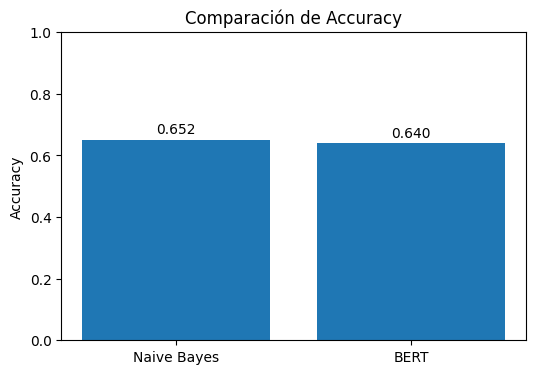

In [11]:
import matplotlib.pyplot as plt

models = ["Naive Bayes", "BERT"]
accuracies = [acc_nb, acc_bert]

plt.figure(figsize=(6,4))
bars = plt.bar(models, accuracies)
plt.title("Comparación de Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

# Mostrar valores encima
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

plt.show()


Para comparar el rendimiento de los modelos implementados, se representó gráficamente la accuracy obtenida por Naive Bayes y por el modelo BERT preentrenado sobre el mismo conjunto de test. Los resultados muestran valores muy similares, con una accuracy ligeramente superior para Naive Bayes (0.65) frente a BERT (0.64). Este resultado pone de manifiesto que, en este caso concreto, un modelo clásico basado en TF-IDF puede ofrecer un rendimiento comparable al de un modelo avanzado de tipo Transformer cuando no se realiza un ajuste específico del modelo al dominio de los datos. La comparación refuerza la importancia de evaluar distintos enfoques y no asumir automáticamente que modelos más complejos garantizan mejores resultados en todos los contextos.

## **PROYECTO 2**


El próposito de esta segunda parte, en el contexto de un hospital, los informes clínicos incluyen información vital sobre los síntomas, diagnósticos, tratamientos y recomendaciones médicas. Sin embargo, estos datos generalmente se almacenan en texto no estructurado, lo que dificulta su análisis en términos cuantitativos automatizados. Para solventarlo, es necesario procesar y estructurar dichos textos.

Ejemplo datos de Kaggle

https://www.kaggle.com/datasets?search=INFORME+

1. Importación de datos

In [1]:
import pandas as pd

dataset = pd.read_csv("/content/mtsamples.csv")
print(dataset.head())
print(dataset.columns)

   Unnamed: 0                                        description  \
0           0   A 23-year-old white female presents with comp...   
1           1           Consult for laparoscopic gastric bypass.   
2           2           Consult for laparoscopic gastric bypass.   
3           3                             2-D M-Mode. Doppler.     
4           4                                 2-D Echocardiogram   

             medical_specialty                                sample_name  \
0         Allergy / Immunology                         Allergic Rhinitis    
1                   Bariatrics   Laparoscopic Gastric Bypass Consult - 2    
2                   Bariatrics   Laparoscopic Gastric Bypass Consult - 1    
3   Cardiovascular / Pulmonary                    2-D Echocardiogram - 1    
4   Cardiovascular / Pulmonary                    2-D Echocardiogram - 2    

                                       transcription  \
0  SUBJECTIVE:,  This 23-year-old white female pr...   
1  PAST MEDICAL 

2. Limpieza y tokenización NLTK


Aplicamos una limpieza ligera del texto clínico utilizando NLTK, preservando números, símbolos y negaciones relevantes para el dominio médico. El texto preprocesado se empleó para análisis léxico y exploración de patrones, mientras que el reconocimiento de entidades nombradas se realizó sobre el texto original para evitar la pérdida de información clínica relevante.

In [2]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import re

nltk.download("punkt")
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))
negations = {"no", "not", "nor", "without"}
stop_words = stop_words - negations

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s\./-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words]
    return " ".join(tokens)

dataset["clean_text"] = dataset["transcription"].apply(clean_text)



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


NER con SpaCy

In [3]:
# Modelo biomédico
!pip install scispacy
!pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_sm-0.5.4.tar.gz

import spacy
nlp = spacy.load("en_core_sci_sm")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.2/33.2 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 78.7 MB/s eta 0:00:00
  Attempting uninstall: blis
    Found existing installation: blis 0.7.11
    Uninstalling blis-0.7.11:
      Successfully uninstalled blis-0.7.11
  Attempting uninstall: thinc
    Found existing installation: thinc 8.2.5
    Uninstalling thinc-8.2.5:
      Successfully uninstalled thinc-8.2.5
  Using cached https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_sm-0.5.4.tar.gz (14.8 MB)
  Preparing metadata (setup.py) ... done
  Using cached spacy-3.7.5-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (27 kB)
  Using cached thinc-8.2.5-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (15 kB)
  Using cached blis-0.7.11-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.4 kB)

/usr/local/lib/python3.12/dist-packages/spacy/language.py:2195: FutureWarning: Possible set union at position 6328
  deserializers["tokenizer"] = lambda p: self.tokenizer.from_disk(  # type: ignore[union-attr]


Debido a la presencia de valores faltantes en algunos informes clínicos, realizaremos una limpieza previa del dataset, eliminando registros sin transcripción válida y asegurando el tipo de dato texto antes de aplicar el modelo de reconocimiento de entidades. Esta etapa es necesarioa en entornos clínicos reales, donde los datos suelen ser incompletos o heterogéneos

In [4]:
#  Limpieza
dataset = dataset.dropna(subset=["transcription"]).copy()
dataset["transcription"] = dataset["transcription"].astype(str).str.strip()
dataset = dataset[dataset["transcription"].str.len() > 0].copy()

#  Extracción  con nlp.pipe
texts = dataset["transcription"].tolist()

entities_list = []
for doc in nlp.pipe(texts, batch_size=32):
    entities_list.append([(ent.text, ent.label_) for ent in doc.ents])

dataset["entities"] = entities_list

# Normalización de entidades
dataset["entities"] = dataset["entities"].apply(
    lambda ents: [(t.strip().lower(), l) for (t, l) in ents]
)

#  Entidades únicas por informe
dataset["unique_entities"] = dataset["entities"].apply(
    lambda ents: sorted(set([t for (t, l) in ents]))
)




3. Análisis de patrones y visualización de la información

A partir de las entidades extraídas, llevamos a cabo un análisis de patrones con el objetivo de identificar regularidades y términos recurrentes en los informes clínicos. Para ello, calcularemos frecuencias de aparición de las entidades y aplicaremos un proceso de normalización y filtrado de términos genéricos, permitiendo distinguir entre información relevante y elementos propios del estilo narrativo clínico. La visualización de estos resultados facilita la interpretación de los datos y proporciona una visión global de los conceptos más frecuentes presentes en el conjunto de informes.

Total de entidades extraídas: 679306

Top 10 TIPOS (labels) más frecuentes:
[('ENTITY', 679306)]

Top 10 ENTIDADES (sin filtrar) más frecuentes:
[('patient', 22664), ('procedure', 4234), ('history', 2429), ('diagnosis', 2420), ('incision', 2192), ('skin', 1994), ('preoperative', 1986), ('removed', 1976), ('prepped', 1769), ('intact', 1630)]

Top 10 ENTIDADES (FILTRADAS) más frecuentes:
[('prepped', 1769), ('intact', 1630), ('pain', 1600), ('negative', 1560), ('closed', 1551), ('draped', 1494), ('operating room', 1409), ('abdomen', 1406), ('bilaterally', 1367), ('level', 1326)]


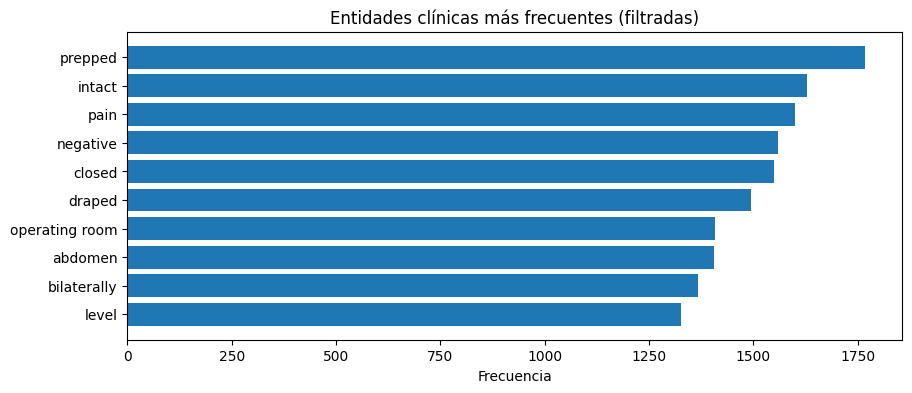

In [5]:
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd

# Aplanar entidades: lista de tuplas (texto_entidad, etiqueta)

flat_entities = [ent for ents in dataset["entities"] for ent in ents]

print("Total de entidades extraídas:", len(flat_entities))

# Normalización básica del texto de entidad
def normalize_entity_text(t: str) -> str:
    t = str(t).lower().strip()
    # normalizar posesivo común en inglés
    t = t.replace("'s", "")
    # compactar espacios
    t = " ".join(t.split())
    return t

#  Contadores: por texto y por etiqueta (tipo)
counter_text = Counter([normalize_entity_text(t) for (t, l) in flat_entities])
counter_label = Counter([l for (t, l) in flat_entities])

print("\nTop 10 TIPOS (labels) más frecuentes:")
print(counter_label.most_common(10))

print("\nTop 10 ENTIDADES (sin filtrar) más frecuentes:")
print(counter_text.most_common(10))

#  Filtrado de entidades genéricas (stoplist) para hacerlo clínicamente informativo
generic = {
    "patient", "procedure", "history", "diagnosis", "preoperative",
    "postoperative", "incision", "removed", "skin", "exam",
    "normal", "present", "day", "mg", "dr", "doctor"
}

filtered_counter = Counter({
    ent: freq for ent, freq in counter_text.items()
    if ent not in generic and len(ent) > 2
})

print("\nTop 10 ENTIDADES (FILTRADAS) más frecuentes:")
top10_filtered = filtered_counter.most_common(10)
print(top10_filtered)

#  Convertir top-10 a DataFrame
top_df = pd.DataFrame(top10_filtered, columns=["entity", "count"])
top_df

#  Visualización del top-10 filtrado
labels = top_df["entity"].tolist()
counts = top_df["count"].tolist()

plt.figure(figsize=(10, 4))
plt.barh(labels, counts)
plt.title("Entidades clínicas más frecuentes (filtradas)")
plt.xlabel("Frecuencia")
plt.gca().invert_yaxis()
plt.show()


4. Estructuración de la información clínica extraída

Una vez extraídas las entidades de los informes clínicos, procedemos a estructurar la información en un formato tabular. Para ello, cada entidad detectada se almacena como una fila independiente, asociándola al identificador del informe del que procede y a su tipo correspondiente. Esta estructuración permite transformar texto clínico no estructurado en datos organizados, facilitando su análisis posterior y su posible integración en sistemas hospitalarios o bases de datos clínicas.

In [6]:
rows = []
for idx, row in dataset.iterrows():
    for ent_text, ent_label in row["entities"]:
        rows.append({
            "report_id": idx,
            "entity": ent_text,
            "entity_type": ent_label
        })

entities_df = pd.DataFrame(rows)

print("Filas en entities_df:", len(entities_df))
entities_df.head()

Filas en entities_df: 679306


,report_id,entity,entity_type
0,0,subjective,ENTITY
1,0,white female,ENTITY
2,0,complaint,ENTITY
3,0,allergies,ENTITY
4,0,allergies,ENTITY


5. Estructuración de la información clínica extraída


Además de la estructuración básica de las entidades extraídas, incorporamos la especialidad médica asociada a cada informe con el fin de contextualizar la información clínica. Esta estructuración permite analizar las entidades detectadas en función del servicio hospitalario, facilitando la identificación de patrones específicos por especialidad y reflejando de forma más realista el uso de sistemas de procesamiento de lenguaje natural en un entorno hospitalario.

In [7]:
"medical_specialty" in dataset.columns


True

In [8]:
rows = []
for idx, row in dataset.iterrows():
    specialty = row["medical_specialty"]
    for ent_text, ent_label in row["entities"]:
        rows.append({
            "report_id": idx,
            "specialty": specialty,
            "entity": ent_text,
            "entity_type": ent_label
        })

entities_spec_df = pd.DataFrame(rows).dropna(subset=["specialty"])

# Filtrar genéricas
entities_spec_df["entity"] = entities_spec_df["entity"].astype(str).str.lower().str.strip()
entities_spec_df = entities_spec_df[~entities_spec_df["entity"].isin(generic)]
entities_spec_df = entities_spec_df[entities_spec_df["entity"].str.len() > 2]

# Top 5 entidades por especialidad
top_by_spec = (
    entities_spec_df.groupby("specialty")["entity"]
    .apply(lambda s: s.value_counts().head(5))
)

top_by_spec.head(25)


specialty                                
Allergy / Immunology        intact             9
                            lesions            9
                            asthma             9
                            bilaterally        9
                            treatment          8
Autopsy                     inch              44
                            neck              36
                            intact            30
                            inches            28
                            body              27
Bariatrics                  abdomen           21
                            surgery           20
                            pounds            19
                            weight loss       14
                            complications     13
Cardiovascular / Pulmonary  catheter         194
                            proximal         155
                            prepped          129
                            wire             121
                            lesion           121
Chiropractic                pain              61
                            mr. abc           25
                            states            24
                            symptoms          19
                            mri               19
Name: entity, dtype: int64

6. Interpretación de resultados en un contexto clínico

Para evaluar el comportamiento del sistema en un contexto clínico real, realizamos una inspección cualitativa de varios informes médicos, comparando el texto original con las entidades detectadas automáticamente. Esta revisión permite comprobar que el pipeline identifica fragmentos relevantes del contenido clínico, así como detectar limitaciones propias del modelo, como la aparición de entidades genéricas o poco específicas, lo cual resulta habitual en enfoques generalistas.

In [9]:
for i in range(3):
    print("==== INFORME", i, "====")
    print(dataset.iloc[i]["transcription"][:400], "...")
    print("\nENTIDADES (primeras 20):")
    print(dataset.iloc[i]["entities"][:20])
    print("\n")


==== INFORME 0 ====
SUBJECTIVE:,  This 23-year-old white female presents with complaint of allergies.  She used to have allergies when she lived in Seattle but she thinks they are worse here.  In the past, she has tried Claritin, and Zyrtec.  Both worked for short time but then seemed to lose effectiveness.  She has used Allegra also.  She used that last summer and she began using it again two weeks ago.  It does not ...

ENTIDADES (primeras 20):
[('subjective', 'ENTITY'), ('white female', 'ENTITY'), ('complaint', 'ENTITY'), ('allergies', 'ENTITY'), ('allergies', 'ENTITY'), ('seattle', 'ENTITY'), ('claritin', 'ENTITY'), ('zyrtec', 'ENTITY'), ('short time', 'ENTITY'), ('lose effectiveness', 'ENTITY'), ('allegra', 'ENTITY'), ('summer', 'ENTITY'), ('weeks', 'ENTITY'), ('working', 'ENTITY'), ('prescription', 'ENTITY'), ('nasal sprays', 'ENTITY'), ('asthma', 'ENTITY'), ('daily medication', 'ENTITY'), ('flaring', 'ENTITY'), ('medication', 'ENTITY')]


==== INFORME 1 ====
PAST MEDICAL HISTORY

Para el reconocimiento de entidades, utlizamos el modelo biomédico en_core_sci_sm de SciSpaCy, que permite identificar menciones relevantes dentro de textos clínicos, aunque emplea un esquema de etiquetado generalista. Como resultado, la mayoría de las entidades extraídas aparecen bajo la etiqueta ENTITY, lo que refleja que el modelo detecta fragmentos potencialmente informativos del texto, pero no diferencia explícitamente entre categorías clínicas específicas como enfermedades, síntomas o tratamientos. Este comportamiento es coherente con las características del modelo. En un entorno hospitalario real, este pipeline podría servir como una primera capa de procesamiento sobre la que incorporar modelos más especializados o reglas clínicas adicionales según las necesidades del caso.